# Cross-Model Baseline — text-metric visualizations

Per-round text-similarity trajectories for the **cross-model baseline** (a MAIN model reads documents
synthesized from a SIDE model's answers; we measure the MAIN model via `run["answer"]`). Driven by the
`evaluation.py` outputs only — **no entity metrics** (`unique_entities` / `entity_similarity` /
collapse-by-simulation are entity-based and intentionally excluded here).

Plain overlaid line charts in the same style as `visualization.ipynb`: each line is a metric averaged
across questions per round. Collapse reads as rising similarity / ROUGE / TES / same-answer% and falling
unique-words over rounds.

**Extensible:** add eval files to `VARIANTS` below. The loader silently skips any that aren't present
yet, so when `replace_one` (or `search`) finishes and is downloaded, just re-run — it joins the plots
automatically.

In [1]:
import os
import json
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt

# ── Config ──
# Local eval files downloaded from Unity (cross-model-baseline/ is gitignored).
EVAL_DIR = "cross-model-baseline/evaluation_outputs"
OUT_DIR  = "cross_model_baseline_visualizations"
os.makedirs(OUT_DIR, exist_ok=True)

# label -> eval filename. Add/remove freely; missing files are skipped.
VARIANTS = {
    "Replace All": "local_replace_all_eval.json",
    "Replace One": "local_replace_one_eval.json",
    "Search":      "local_search_eval.json",
}

# colors match visualization.ipynb / agentic-rag-visualization.ipynb
COLORS = {
    "Replace All": "#1f77b4",
    "Replace One": "#ff7f0e",
    "Search":      "#2ca02c",
}

In [2]:
# ── Load whatever eval files are present ──
eval_data = {}
for label, fname in VARIANTS.items():
    path = os.path.join(EVAL_DIR, fname)
    if os.path.isfile(path):
        with open(path, "r", encoding="utf-8") as f:
            eval_data[label] = json.load(f)
        nq = len(eval_data[label]["questions"])
        nr = len(eval_data[label]["questions"][0]["iterations"]) if nq else 0
        print(f"loaded  {label:12s} <- {fname}  ({nq} questions, {nr} rounds)")
    else:
        print(f"skipped {label:12s} (not found: {path})")

assert eval_data, f"No eval files found under {EVAL_DIR}/"

loaded  Replace All  <- local_replace_all_eval.json  (400 questions, 10 rounds)
loaded  Replace One  <- local_replace_one_eval.json  (400 questions, 20 rounds)
skipped Search       (not found: cross-model-baseline/evaluation_outputs\local_search_eval.json)


In [3]:
# ── Aggregate a metric across questions, per round ──
def per_round(experiment, key):
    """Return (rounds, means, sems) for metric `key`, averaged across questions per round."""
    buckets = defaultdict(list)
    for q in experiment["questions"]:
        for it in q["iterations"]:
            m = it.get("metrics", {})
            v = m.get(key)
            if v is not None:
                buckets[it["iteration_number"]].append(v)
    rounds = sorted(buckets)
    means = np.array([np.mean(buckets[r]) for r in rounds])
    sems  = np.array([np.std(buckets[r]) / np.sqrt(len(buckets[r])) for r in rounds])
    return np.array(rounds), means, sems


# Metrics to plot: (json_key, title, y-axis label). Higher = more collapse, except unique_words.
METRICS = [
    ("avg_pairwise_similarity", "Cosine similarity across runs",  "avg pairwise cosine"),
    ("avg_pairwise_rougeL",     "ROUGE-L across runs",           "avg pairwise ROUGE-L"),
    ("avg_pairwise_tes",        "Token-edit similarity (TES)",   "avg pairwise TES"),
    ("same_answer_percentage",  "Same-answer % (LLM judge)",     "same-answer %"),
    ("unique_words",            "Unique words (round union)",    "unique words"),
    ("ai_reference_percentage", "AI-reference %",                "ai-reference %"),
]

wrote cross_model_baseline_visualizations\avg_pairwise_similarity_per_round.png


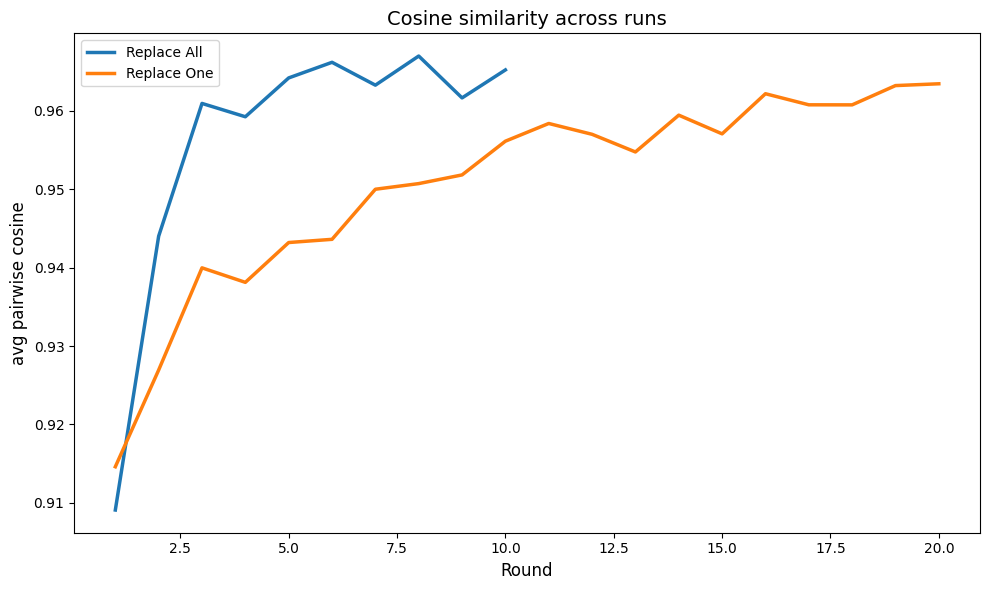

wrote cross_model_baseline_visualizations\avg_pairwise_rougeL_per_round.png


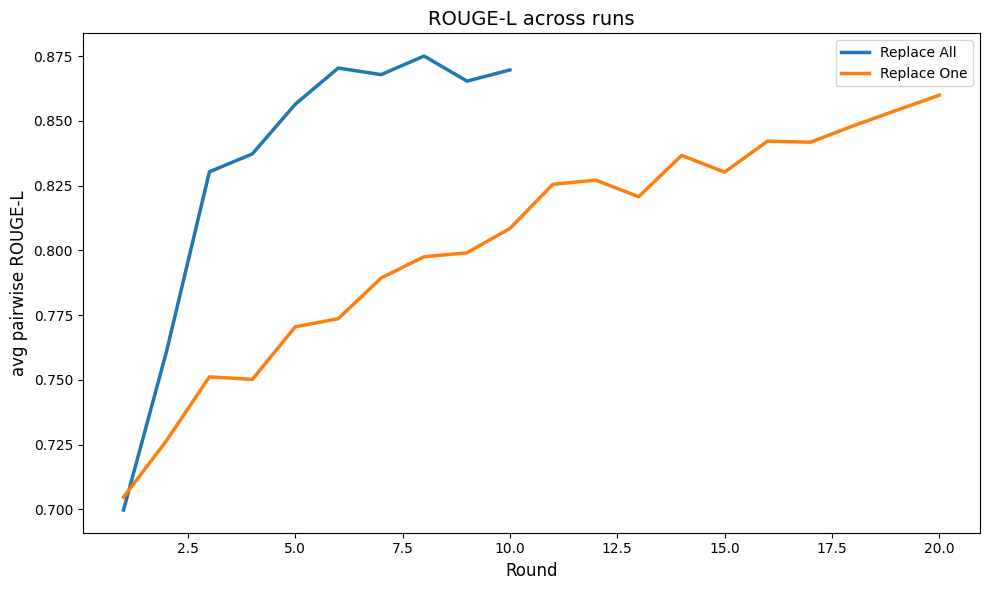

wrote cross_model_baseline_visualizations\avg_pairwise_tes_per_round.png


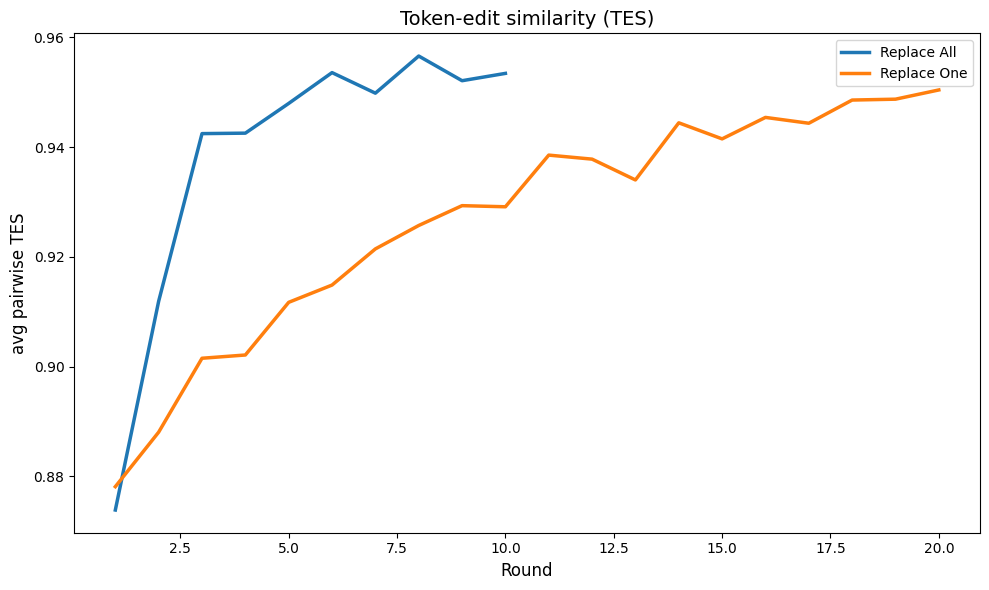

wrote cross_model_baseline_visualizations\same_answer_percentage_per_round.png


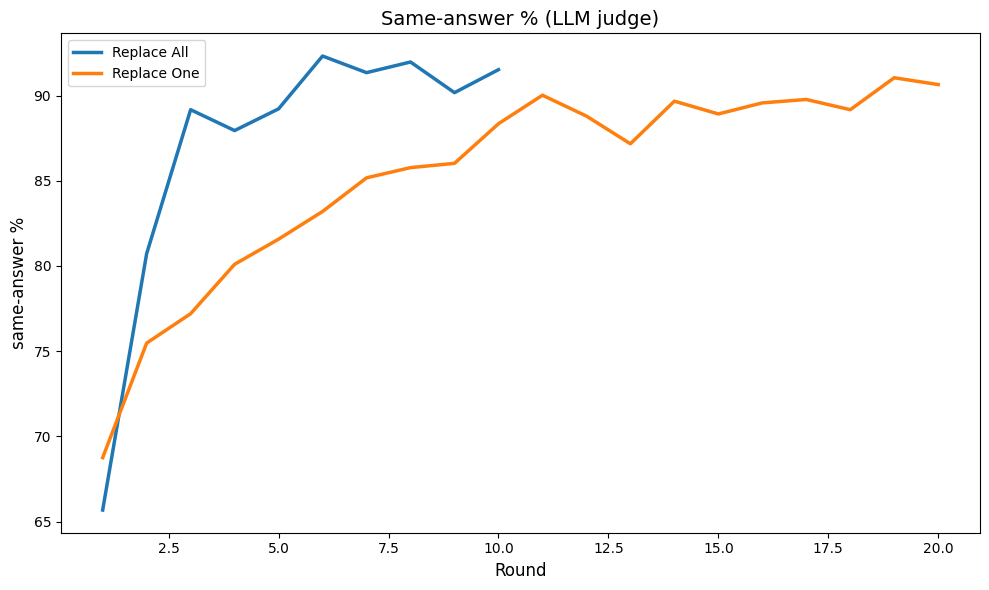

wrote cross_model_baseline_visualizations\unique_words_per_round.png


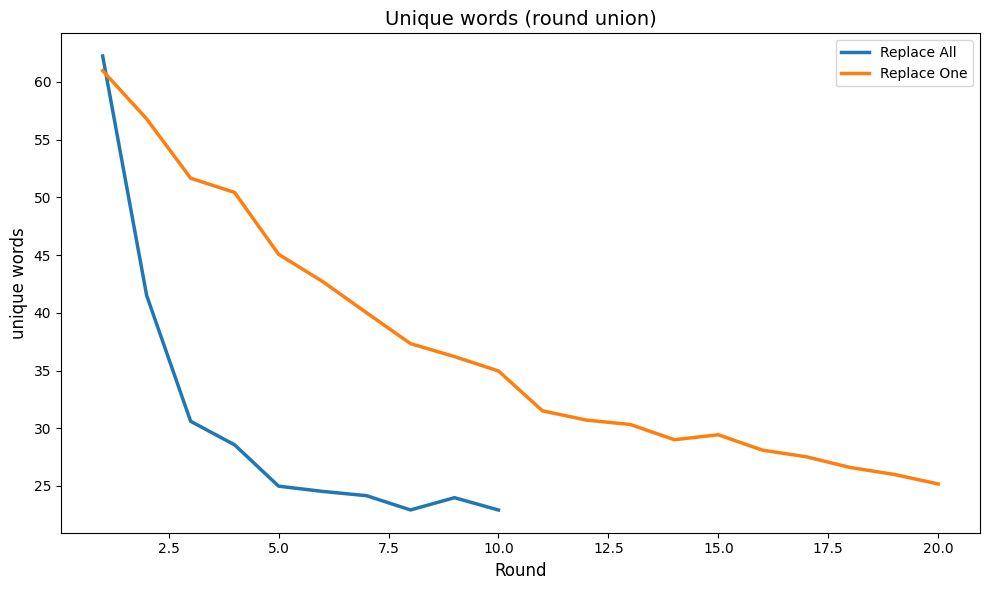

wrote cross_model_baseline_visualizations\ai_reference_percentage_per_round.png


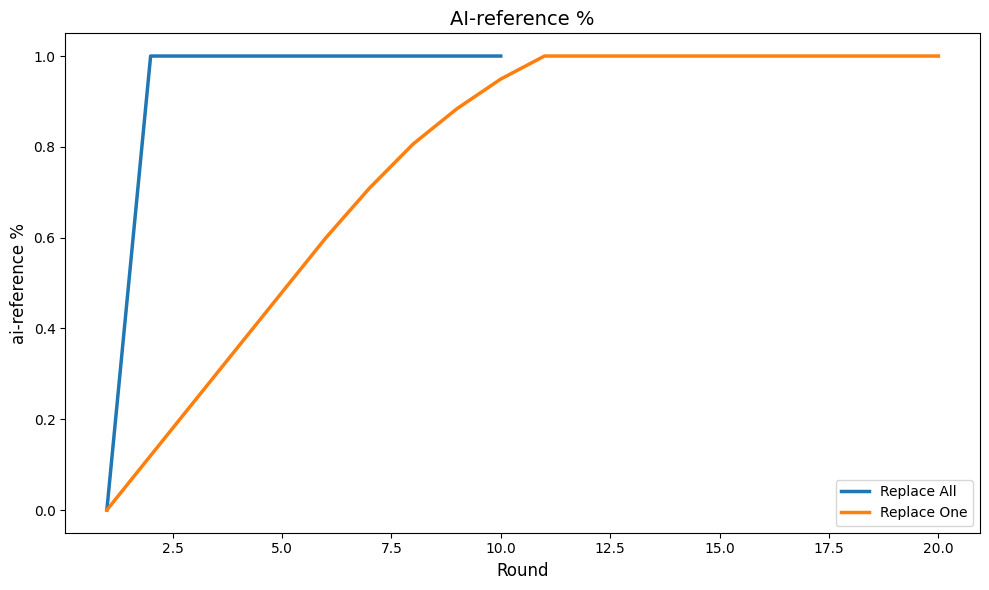

In [4]:
# ── One figure per metric (overlaid variants), visualization.ipynb line style ──
def plot_metric(key, title, ylabel, save=True):
    fig, ax = plt.subplots(figsize=(10, 6))
    for label, exp in eval_data.items():
        rounds, means, _ = per_round(exp, key)
        if len(rounds) == 0:
            continue
        # 1-indexed integer rounds on the x-axis, like visualization.ipynb
        ax.plot(range(1, len(means) + 1), means, linewidth=2.5, color=COLORS.get(label), label=label)
    ax.set_xlabel("Round", fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(title, fontsize=14)
    ax.legend()
    plt.tight_layout()
    if save:
        out = os.path.join(OUT_DIR, f"{key}_per_round.png")
        plt.savefig(out, dpi=150, bbox_inches="tight")
        print("wrote", out)
    plt.show()


for key, title, ylabel in METRICS:
    plot_metric(key, title, ylabel)

wrote cross_model_baseline_visualizations\all_metrics_per_round.png


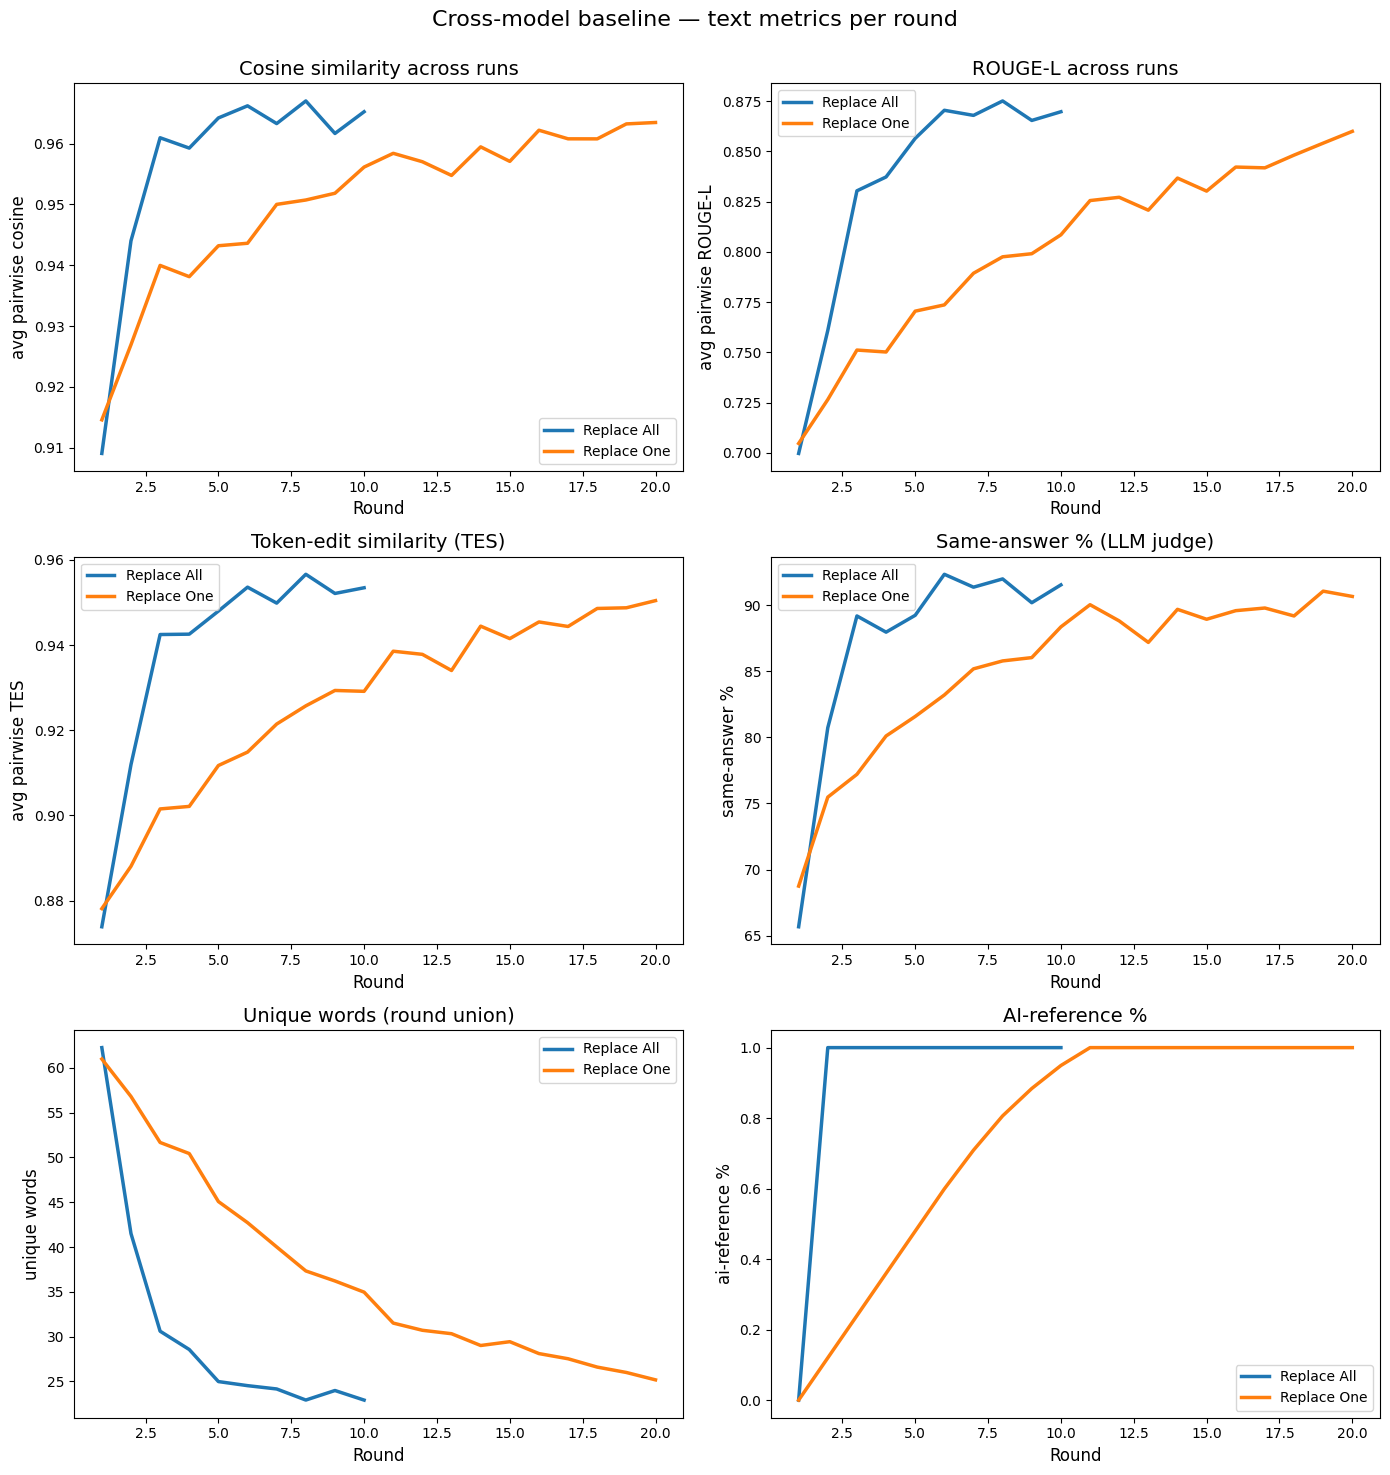

In [5]:
# ── Combined grid (all metrics in one figure), plain lines ──
ncol = 2
nrow = (len(METRICS) + ncol - 1) // ncol
fig, axes = plt.subplots(nrow, ncol, figsize=(14, 5 * nrow))
axes = np.array(axes).reshape(-1)

for ax, (key, title, ylabel) in zip(axes, METRICS):
    for label, exp in eval_data.items():
        rounds, means, _ = per_round(exp, key)
        if len(rounds) == 0:
            continue
        # 1-indexed integer rounds on the x-axis, like visualization.ipynb
        ax.plot(range(1, len(means) + 1), means, linewidth=2.5, color=COLORS.get(label), label=label)
    ax.set_title(title, fontsize=14)
    ax.set_xlabel("Round", fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.legend()

for ax in axes[len(METRICS):]:
    ax.set_visible(False)

fig.suptitle("Cross-model baseline — text metrics per round", fontsize=16)
fig.tight_layout(rect=[0, 0, 1, 0.98])
out = os.path.join(OUT_DIR, "all_metrics_per_round.png")
fig.savefig(out, dpi=150, bbox_inches="tight")
print("wrote", out)
plt.show()

## Entity-collapse diagrams (cross-model)

Recomputed from the per-question `*.entities_by_round.jsonl` **cross-model** files (Qwen main model,
GPT-5.2-tagged) in the latest `entity re-run for workshop paper-*` dump (auto-discovered by regex).
Three diagrams in the `visualization.ipynb` style, overlaying Replace All + Replace One:

- `unique_entities_per_round.png` — union of canonical entities across the 10 runs, averaged over questions
- `entity_similarity_per_round.png` — mean pairwise cosine similarity of binary entity-mention vectors
- `collapse_by_simulation.png` — % of question-rounds where all 10 runs share one entity set
  (error bars: 95% Wilson CI)

entity dump: entity re-run for workshop paper-20260630T060414Z-3-001\entity re-run for workshop paper


loaded Replace All: 10 rounds


loaded Replace One: 20 rounds


wrote cross_model_baseline_visualizations\unique_entities_per_round.png


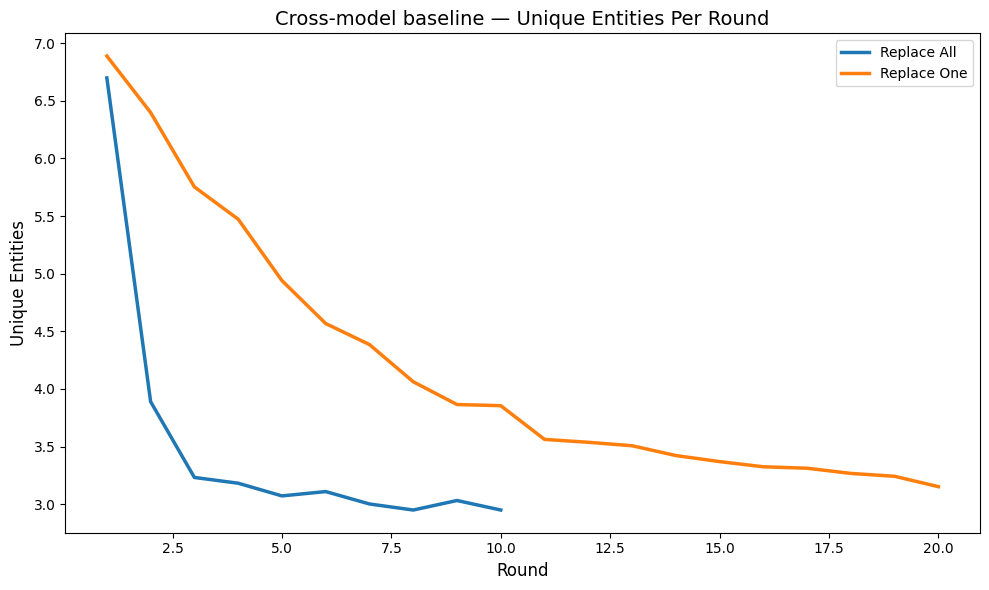

wrote cross_model_baseline_visualizations\entity_similarity_per_round.png


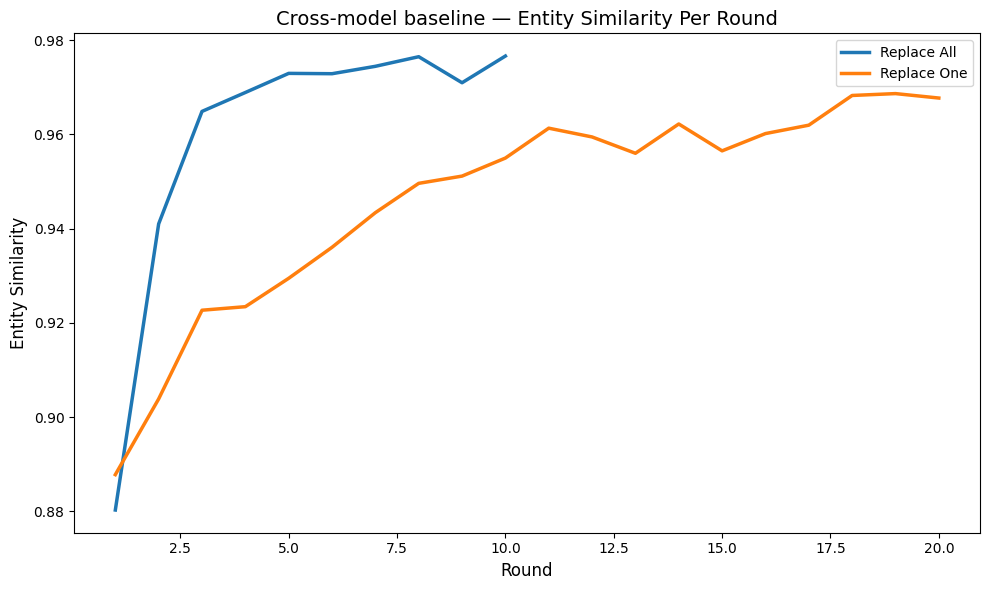

wrote cross_model_baseline_visualizations\collapse_by_simulation.png


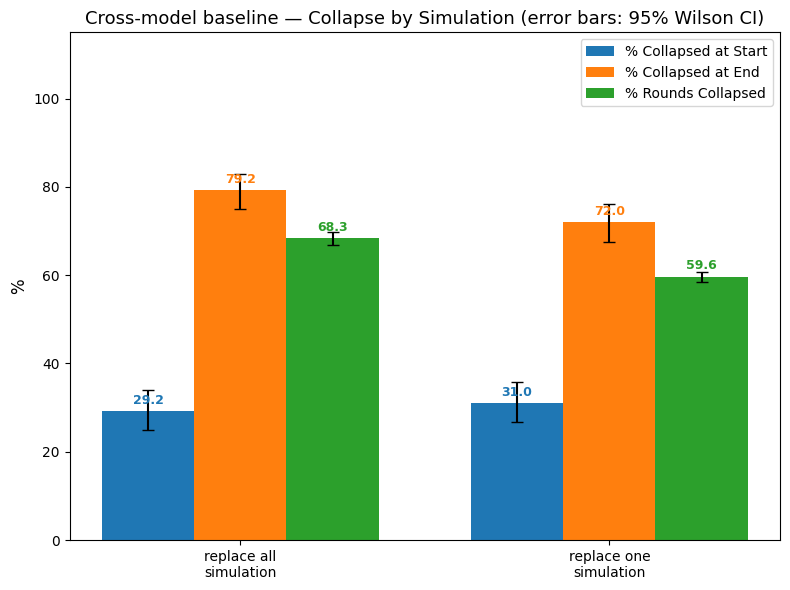

In [6]:
# ── Cross-model entity diagrams (unique entities / entity similarity / collapse-by-simulation) ──
import re
from scipy.stats import binomtest

# Auto-discover the newest entity re-run dump in the repo root (gitignored; timestamp varies).
_PAT = re.compile(r"entity re-run for workshop paper-.*")
_outer = sorted(d for d in os.listdir(".") if _PAT.fullmatch(d) and os.path.isdir(d))
if not _outer:
    raise FileNotFoundError("No 'entity re-run for workshop paper-*' folder in the repo root.")
_inner = [d for d in os.listdir(_outer[-1]) if os.path.isdir(os.path.join(_outer[-1], d))]
ENTITY_BASE = os.path.join(_outer[-1], _inner[0]) if _inner else _outer[-1]
print("entity dump:", ENTITY_BASE)

# Cross-model files: Qwen main model, documents synthesised from the side model's answers.
CROSS_FILES = {
    "Replace All": (COLORS["Replace All"],
        "model_collapse_log_graphite_cross_model_replace_all_Qwen_Qwen2.5-14B-Instruct_local_replace_all.entities_by_round.jsonl"),
    "Replace One": (COLORS["Replace One"],
        "model_collapse_log_graphite_cross_model_replace_one_Qwen_Qwen2.5-14B-Instruct_local_replace_one.entities_by_round.jsonl"),
}

def _entity_similarity(vectors):
    n = len(vectors)
    if n < 2:
        return 0.0
    s = []
    for i in range(n):
        for j in range(i + 1, n):
            a, b = vectors[i], vectors[j]
            na, nb = np.linalg.norm(a), np.linalg.norm(b)
            s.append(float(np.dot(a, b) / (na * nb)) if na > 0 and nb > 0 else 0.0)
    return float(np.mean(s))

def analyze_entity_file(path):
    """Per-round mean unique-entity count and mean entity similarity (matches entity_extraction.py)."""
    pru, prs, mx = defaultdict(list), defaultdict(list), 0
    with open(path, encoding="utf-8") as fh:
        for line in fh:
            rec = json.loads(line)
            rounds, counts, mapped = rec["round_numbers"], rec["entity_counts"], rec["mapped_entities"]
            mx = max(mx, len(rounds))
            for idx in range(len(rounds)):
                pru[idx].append(len(counts[idx]))
                runs = mapped[idx]
                vocab = sorted({e for run in runs for e in run})
                vi = {e: i for i, e in enumerate(vocab)}
                vecs = []
                for run in runs:
                    v = np.zeros(len(vocab))
                    for e in run:
                        v[vi[e]] = 1.0
                    vecs.append(v)
                prs[idx].append(_entity_similarity(vecs))
    return ([float(np.mean(pru[i])) for i in range(mx)], [float(np.mean(prs[i])) for i in range(mx)])

def _wilson(count, nobs):
    if nobs == 0:
        return 0.0, 0.0, 0.0
    count, nobs = int(round(count)), int(round(nobs))
    ci = binomtest(count, nobs).proportion_ci(confidence_level=0.95, method="wilson")
    return 100.0 * count / nobs, 100.0 * ci.low, 100.0 * ci.high

def collapse_metrics(path):
    """% of question-rounds collapsed (all 10 runs share one canonical entity set), with 95% Wilson CIs:
    collapsed at first/last round (over questions) and pooled over all (question, round) cells."""
    n = ns = ne = cr = tr = 0
    with open(path, encoding="utf-8") as fh:
        for line in fh:
            rec = json.loads(line)
            mapped = rec["mapped_entities"]
            nr = len(rec["round_numbers"])
            flags = [len({frozenset(run) for run in mapped[i]}) == 1 for i in range(nr)]
            if not flags:
                continue
            n += 1; ns += int(flags[0]); ne += int(flags[-1]); cr += sum(flags); tr += len(flags)
    return {"start": _wilson(ns, n), "end": _wilson(ne, n), "rounds": _wilson(cr, tr)}

# Load + compute
ent = {}
for label, (color, fname) in CROSS_FILES.items():
    path = os.path.join(ENTITY_BASE, fname)
    if not os.path.exists(path):
        print("  MISSING:", fname); continue
    u, s = analyze_entity_file(path)
    ent[label] = {"color": color, "unique": u, "similarity": s, "collapse": collapse_metrics(path)}
    print(f"loaded {label}: {len(u)} rounds")
assert ent, "No cross-model entity files found in the dump."

# 1) + 2) unique entities and entity similarity (overlaid line charts)
for which, ylabel, title, fn in [
    ("unique", "Unique Entities", "Unique Entities Per Round", "unique_entities_per_round.png"),
    ("similarity", "Entity Similarity", "Entity Similarity Per Round", "entity_similarity_per_round.png")]:
    fig, ax = plt.subplots(figsize=(10, 6))
    for label, d in ent.items():
        vals = d[which]
        ax.plot(range(1, len(vals) + 1), vals, linewidth=2.5, label=label, color=d["color"])
    ax.set_xlabel("Round", fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(f"Cross-model baseline — {title}", fontsize=14)
    ax.legend()
    plt.tight_layout()
    out = os.path.join(OUT_DIR, fn)
    plt.savefig(out, dpi=150, bbox_inches="tight")
    print("wrote", out)
    plt.show()

# 3) collapse by simulation (grouped bars, 95% Wilson CI)
sims = list(ent.keys())
x = np.arange(len(sims)); width = 0.25
fig, ax = plt.subplots(figsize=(8, 6))
for k, label, color, off in [
    ("start",  "% Collapsed at Start", "#1f77b4", -width),
    ("end",    "% Collapsed at End",   "#ff7f0e", 0.0),
    ("rounds", "% Rounds Collapsed",   "#2ca02c", width)]:
    p  = np.array([ent[s]["collapse"][k][0] for s in sims])
    lo = np.array([ent[s]["collapse"][k][1] for s in sims])
    hi = np.array([ent[s]["collapse"][k][2] for s in sims])
    yerr = np.vstack([p - lo, hi - p])
    bars = ax.bar(x + off, p, width, yerr=yerr, capsize=4, label=label, color=color)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
                f"{bar.get_height():.1f}", ha="center", va="bottom",
                fontsize=9, fontweight="bold", color=color)
ax.set_ylabel("%", fontsize=12)
ax.set_title("Cross-model baseline — Collapse by Simulation (error bars: 95% Wilson CI)", fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels([f"{s.lower()}\nsimulation" for s in sims], fontsize=10)
ax.legend(loc="upper right")
ax.set_ylim(0, 115)
plt.tight_layout()
out = os.path.join(OUT_DIR, "collapse_by_simulation.png")
plt.savefig(out, dpi=150, bbox_inches="tight")
print("wrote", out)
plt.show()